<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
    Machine learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 5 - NLP - Word Embeddings & Fine-Tuning <br>
</div>
<div dir=ltr align=center>
<font color=0CBCDF size=4>
     Emad Rostamian, Seyed Moein Ayyoubzadeh
<br>
<font color=0CBCDF size=4>
</div>

____

<font color=9999FF size=4>
Full Name : Reyhane Khayatzade Mahani
<br>
<font color=9999FF size=4>
Student Number : 402105965

<font color=0080FF size=3>
This notebook covers two related topics in modern NLP. In the first part, we study word embedding methods, including traditional and neural approaches, to understand how semantic information is represented in vector space. In the second part, we explore fine-tuning strategies for pretrained language models, with a focus on parameter-efficient methods such as LoRA, and analyze their behavior during training.
</font>

# Section 1: Exploring Word Embeddings

## 🎯 Objective

In this section, you will **build, explore, and compare different types of word representations (embeddings)** to understand how machines capture the meaning of words from text.


---

## 📚 Dataset

We will work with the complete **_Harry Potter_ series (Books 1–7)**, loaded from a public Hugging Face dataset.

⚠️ **Note:** This text is used **only for educational purposes**.


---

## 🛠️ What You Will Do

You will:
1. **Implement from scratch**
   - TF-IDF
   - Word2Vec-style embeddings (CBOW and Skip-Gram)
   - Nearest-neighbor search (word similarity)
2. **GloVe: Global Vectors for Word Representation**
   - Exploring word vectors
   - Word Analogies

## Part 1: Implement from scratch

## 1. Traditional Word Representations: TF-IDF

Before learning dense vector embeddings, we start with a **traditional and interpretable** way of representing words: **TF-IDF**.

TF-IDF does *not* try to learn meaning from prediction tasks. Instead, it represents words based on how **frequently** they appear and how **informative** they are across documents.

---

## Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

For a word $ w $ in document $ d $:

$$
\text{TF}(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total number of words in } d}
$$

Intuition:
- Words that appear often in a document are likely important *for that document*

---

## Inverse Document Frequency (IDF)

Inverse Document Frequency downweights words that appear in *many* documents.

$$
\text{IDF}(w) = \log\left(\frac{1 + N}{1 + \text{DF}(w)}\right) + 1
$$

Where:
- $ N $ = total number of documents  
- $ \text{DF}(w) $ = number of documents containing word \( w \)

Why the **+1** terms:
- `+1` in the denominator prevents division by zero  
- `+1` in the numerator keeps the ratio ≥ 1  
- `+1` outside the log prevents zero IDF values  

Intuition:
- Common words get low weight  
- Rare words get high weight  
- All words keep a positive contribution  


---

## TF-IDF Score

The final TF-IDF representation combines both ideas:

$$
\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \text{IDF}(w)
$$

Each document is represented as a **high-dimensional sparse vector**, where:
- Each dimension corresponds to a word in the vocabulary
- Values reflect word importance


---

## Your Task

In this section, you will:

1. Load **Harry Potter and the Sorcerer’s Stone**
2. Split the book into **chapters** (each chapter = one document)
3. Build **TF-IDF vectors from scratch**
4. Use TF-IDF to:
   - Find the most important words in a chapter
   - Compute similarity between chapters
   - Compare words based on their TF-IDF representations

Do **not** use `sklearn`’s `TfidfVectorizer`.

The goal is to understand *how TF-IDF works internally*.


In [1]:
# Standard library
import re
import math
import random
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Hugging Face
from datasets import load_dataset

# Scikit-learn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Load dataset
hp_ds = load_dataset("elricwan/HarryPotter")

# Each book is one document
books = hp_ds["train"]

# Extract book texts
documents = [book["content"] for book in books]
documents = documents[:-1]
print(f"Number of books: {len(documents)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/353 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.81M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8 [00:00<?, ? examples/s]

Number of books: 7


In [3]:
# TODO: Preprocessing : Normalize text and remove punctuation and stopwords
def preprocess(text):
    # Lowercase the text
    text = text.lower()
    # Remove punctuation and non-alphabetic characters, keeping only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize by splitting on whitespace
    tokens = text.split()
    # Remove stopwords and empty tokens
    tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS and len(token) > 0]
    return tokens

docs = [preprocess(doc) for doc in documents]

# TODO: Print number of Tokens in each book(doc)
for i, doc in enumerate(docs):
    print(f"Book {i+1} tokens: {len(doc)}")

Book 1 tokens: 38732
Book 2 tokens: 44821
Book 3 tokens: 55451
Book 4 tokens: 95315
Book 5 tokens: 126665
Book 6 tokens: 82098
Book 7 tokens: 94423


In [4]:
# TODO: Build a shared corpus and initial vocabulary
corpus = []
for doc in docs:
    corpus.extend(doc)

word_counts = Counter(corpus)

# TODO: Remove rare words below frequency threshold
min_freq = 2
vocab = sorted([word for word, count in word_counts.items() if count >= min_freq])

# TODO: Create word ↔ index lookup tables
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

# TODO: Filter corpus to known vocabulary and convert to indices
corpus_idxs = [word2idx[word] for word in corpus if word in word2idx]

# TODO: Print corpus size and vocabulary size
print(f"Vocabulary size: {len(vocab)}")
print(f"Corpus size: {len(corpus_idxs)}")

Vocabulary size: 15298
Corpus size: 529934


In [5]:
# TODO: Compute TF
def tf(doc):
    total_words = len(doc)
    word_count = Counter(doc)
    tf_vec = np.zeros(len(vocab))
    for word, count in word_count.items():
        if word in word2idx:
            idx = word2idx[word]
            tf_vec[idx] = count / total_words
    return tf_vec

tf_docs = [tf(doc) for doc in docs]

# TODO: Compute IDF
def idf(docs):
    N = len(docs)
    df = np.zeros(len(vocab))
    for doc in docs:
        doc_set = set(doc)
        for word in doc_set:
            if word in word2idx:
                idx = word2idx[word]
                df[idx] += 1
    idf_vec = np.log((1 + N) / (1 + df)) + 1
    return idf_vec

idf = idf(docs)

# TODO:Compute TF-IDF
def compute_tfidf(tf, idf):
    tfidf = tf * idf
    return tfidf

tfidf_docs = [compute_tfidf(tf_d, idf) for tf_d in tf_docs]

In [6]:
# TODO: Extract and display top TF-IDF terms per document

def top_k_words(tfidf_doc, k=5):
    # TODO: Return the k highest-scoring terms in a TF-IDF vector
    indices = np.argsort(tfidf_doc)[::-1][:k]
    top_terms = [(idx2word[idx], tfidf_doc[idx]) for idx in indices if idx in idx2word]
    return top_terms

for i, tfidf_doc in enumerate(tfidf_docs):
    # TODO: Print most informative words for each document
    print(f"\nBook {i+1}")
    for word, score in top_k_words(tfidf_doc, k=5):
        print(f"  {word:<15} {score:.4f}")


Book 1
  harry           0.0333
  said            0.0212
  ron             0.0107
  hagrid          0.0087
  hermione        0.0068

Book 2
  harry           0.0357
  said            0.0272
  ron             0.0150
  hermione        0.0066
  lockhart        0.0065

Book 3
  harry           0.0341
  said            0.0272
  ron             0.0130
  hermione        0.0115
  lupin           0.0086

Book 4
  harry           0.0318
  said            0.0281
  ron             0.0104
  hermione        0.0087
  dumbledore      0.0056

Book 5
  said            0.0316
  harry           0.0296
  hermione        0.0096
  ron             0.0094
  umbridge        0.0066

Book 6
  harry           0.0320
  said            0.0300
  dumbledore      0.0108
  ron             0.0097
  slughorn        0.0082

Book 7
  harry           0.0308
  said            0.0210
  hermione        0.0118
  ron             0.0113
  wand            0.0061


In [7]:
def tfidf_vector_for_word(word, tfidf_docs):
    # TODO: Collect TF-IDF scores of a given word across all documents
    if word not in word2idx:
        return [0.0] * len(tfidf_docs)
    idx = word2idx[word]
    scores = [tfidf_doc[idx] for tfidf_doc in tfidf_docs]
    return scores

# Select a target word to analyze
word = "harry"

# TODO: Compute the word’s TF-IDF distribution across documents
harry_tfidf = tfidf_vector_for_word(word, tfidf_docs)

# TF-IDF values per chapter
harry_tfidf

[np.float64(0.033331612103686875),
 np.float64(0.03571986345686174),
 np.float64(0.03410218030333087),
 np.float64(0.03184178775638672),
 np.float64(0.02958986302451348),
 np.float64(0.03199834344320203),
 np.float64(0.03083994365779524)]

### Questions


1.   In the TF-IDF vector you just computed for the word "harry", what does each element of the vector represent?


> Each element in the vector represents the TF-IDF score (importance) of the word "harry" in one specific document (book) from the Harry Potter series. For example, the first element (≈0.1009) is its score in Book 1, reflecting how frequently and uniquely "harry" appears there relative to the entire corpus.



2.   In your own words, what are the main limitations of TF-IDF as a word representation? Consider whether TF-IDF captures meaning, similarity between words, and relationships such as analogies.

> TF-IDF is a statistical method that creates sparse, high-dimensional vectors based on word frequencie, making it great for tasks like document retrieval but limited for deeper semantics. It doesn't capture meaning because it attends to context or synonyms. For similarity, cosine distance might highlight topical overlap (like shared rare terms) but fails on semantic nuance, and it often treats unrelated frequent words as dissimilar even if conceptually close. it can't handle analogies or vector arithmetic since vectors encode counts, not relational embeddings, leading to brittle representations in tasks needing inference or generalization.



## 2. Word2Vec: CBOW and Skip-Gram

TF-IDF represents words using **counts and statistics**, but it does not capture *semantic meaning*.
To go beyond this, we rely on a key idea in linguistics and NLP:

> **You shall know a word by the company it keeps.**

This idea is known as the **distributional hypothesis**.

Instead of counting words, we now **learn** word vectors by training a model to predict words from their surrounding context.

---

## Word2Vec: Learning Word Embeddings

Word2Vec learns *static* (context-independent) word embeddings by solving a **prediction task**.
However, directly predicting a word from the entire vocabulary using a softmax is computationally expensive.

To make training efficient, Word2Vec uses **negative sampling**.

---

## Word2Vec: Two Training Objectives

Word2Vec uses one of two training objectives to generate these positive and negative examples:

### 🔹 CBOW (Continuous Bag of Words)
- **Input:** surrounding context words
- **Target:** the center word

### 🔹 Skip-Gram
- **Input:** center word
- **Target:** surrounding context words
---
### 🔹 What is Negative Sampling?

Negative sampling reformulates word prediction as a **binary classification problem**:

- **Positive examples**: word pairs that actually occur together in the text
- **Negative examples**: randomly sampled word pairs that do *not* occur together

Instead of scoring against the whole vocabulary, the model only compares:
- one true (positive) word
- a small number of randomly sampled (negative) words

This dramatically reduces computation while still producing high-quality embeddings.

### 🔹 Why Negative Sampling Works

By training the model to:
- **increase similarity** for real context–word pairs
- **decrease similarity** for randomly sampled pairs

 the learned vectors capture semantic and syntactic relationships between words.

---

In this section, you will:

1. Generate **(context, target)** training pairs from text  
2. Implement **CBOW and Skip-Gram with negative sampling from scratch**  
3. Train word embeddings using a simple neural objective  
4. Explore the learned embeddings by:
   - Finding nearest neighbors
   - Performing word analogies
   - Comparing CBOW vs Skip-Gram behavior

Do **not** use `gensim` or prebuilt Word2Vec implementations.

The goal is to understand **how embeddings are learned**, not just how to use them.


### Build sliding windows

Use `torch.unfold` to create windows of size `2w+1`, then split into:
- `centers`: middle token  
- `contexts`: left+right tokens (center removed)


In [8]:
def make_windows(corpus_idxs, window_size):
    #TODO
    corpus_tensor = torch.tensor(corpus_idxs)
    window_size_full = 2 * window_size + 1
    windows = corpus_tensor.unfold(0, window_size_full, 1)
    centers = windows[:, window_size]
    contexts = torch.cat([windows[:, :window_size], windows[:, window_size + 1:]], dim=1)
    return contexts, centers

### Negative-sampling distribution

Build the unigram distribution $P(w) \propto \text{count}(w)^{0.75}$ for sampling negative words.


In [9]:
def build_unigram_dist(word_counts, vocab_size, word2idx, power=0.75):
    #TODO:
    counts = np.array([word_counts.get(idx2word[i], 0) for i in range(vocab_size)])
    powered = counts ** power
    dist = powered / powered.sum()
    return torch.tensor(dist, dtype=torch.float32)

unigram_dist = build_unigram_dist(word_counts, len(vocab), word2idx)

### Negative sampling utilities

Sample $k$ negative words per example and compute the **negative sampling loss**:  

$$\log\sigma(s^{+}) + \sum \log\sigma(-s^{-})$$


In [10]:
@torch.no_grad()
def sample_negatives(dist_on_device, batch_size, k):
    #TODO:
    num_samples = batch_size * k
    neg_samples = torch.multinomial(dist_on_device, num_samples=num_samples, replacement=True)
    neg_samples = neg_samples.view(batch_size, k)
    return neg_samples

def negative_sampling_loss(pos_score, neg_score):
    #TODO:
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    loss = -(pos_loss + neg_loss).mean()
    return loss

### CBOW
Create a CBOW dataset (`contexts → center`) and a CBOW model that returns positive/negative scores for the **negative sampling loss**.


In [11]:
class CBOWDataset(Dataset):
    def __init__(self, contexts, centers):
        #TODO:
        self.contexts = contexts
        self.centers = centers

    def __len__(self):
        #TODO:
        return len(self.centers)

    def __getitem__(self, idx):
        #TODO:
        return self.contexts[idx], self.centers[idx]

In [12]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        #TODO:
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, context_idxs, target_idxs, neg_idxs):
        #TODO:
        context_emb = self.in_embeddings(context_idxs)  # batch x ctx_len x dim
        ctx_avg = context_emb.mean(dim=1)  # batch x dim

        target_emb = self.out_embeddings(target_idxs)  # batch x dim
        neg_emb = self.out_embeddings(neg_idxs)  # batch x k x dim

        pos_score = (ctx_avg * target_emb).sum(dim=1)  # batch
        neg_score = (ctx_avg.unsqueeze(1) * neg_emb).sum(dim=2)  # batch x k

        return pos_score, neg_score

#### Train CBOW

Training loop for CBOW: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [13]:
def train_cbow(model, loader, dist, optimizer, neg_k, epochs):
    #TODO:
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        progress = tqdm(loader, desc=f"CBOW-NS Epoch {epoch+1}")
        for contexts, centers in progress:
            batch_size = len(centers)
            neg_idxs = sample_negatives(dist.to(device), batch_size, neg_k)
            contexts = contexts.to(device)
            centers = centers.to(device)
            optimizer.zero_grad()
            pos_score, neg_score = model(contexts, centers, neg_idxs)
            loss = negative_sampling_loss(pos_score, neg_score)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(loader)
        print(f"CBOW-NS Epoch {epoch+1} avg loss: {avg_loss:.4f}")

In [14]:
window_size = 2
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

CBOW_BATCH = 2048
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for CBOW
cbow_dataset = CBOWDataset(contexts, centers)
cbow_loader = DataLoader(cbow_dataset, batch_size=CBOW_BATCH, shuffle=True)
#TODO: Initialize CBOW model and optimizer
cbow = CBOW(len(vocab), EMBED_DIM).to(device)
cbow_opt = optim.Adam(cbow.parameters(), lr=LR)
#TODO: Train the model
train_cbow(cbow, cbow_loader, unigram_dist, cbow_opt, NEG_K, EPOCHS)

CBOW-NS Epoch 1: 100%|██████████| 259/259 [00:05<00:00, 44.03it/s, loss=11.1]


CBOW-NS Epoch 1 avg loss: 14.5078


CBOW-NS Epoch 2: 100%|██████████| 259/259 [00:06<00:00, 43.08it/s, loss=5.92]


CBOW-NS Epoch 2 avg loss: 7.8668


CBOW-NS Epoch 3: 100%|██████████| 259/259 [00:05<00:00, 46.67it/s, loss=4.52]


CBOW-NS Epoch 3 avg loss: 5.0582


CBOW-NS Epoch 4: 100%|██████████| 259/259 [00:05<00:00, 44.56it/s, loss=4.1]


CBOW-NS Epoch 4 avg loss: 4.2411


CBOW-NS Epoch 5: 100%|██████████| 259/259 [00:05<00:00, 49.74it/s, loss=3.73]

CBOW-NS Epoch 5 avg loss: 3.8302


### Skip-gram

Create (`center`, `context`) training pairs and a Skip-gram model that scores positive and negative contexts for the negative sampling loss.


In [15]:
class SkipGramPairDataset(Dataset):
    def __init__(self, contexts, centers):
        #TODO
        self.centers_list = []
        self.pos_contexts_list = []
        for i in range(len(centers)):
            center = centers[i]
            for ctx in contexts[i]:
                self.centers_list.append(center)
                self.pos_contexts_list.append(ctx)
        self.centers = torch.tensor(self.centers_list)
        self.pos_contexts = torch.tensor(self.pos_contexts_list)

    def __len__(self):
        #TODO
        return len(self.centers)

    def __getitem__(self, idx):
        #TODO
        return self.centers[idx], self.pos_contexts[idx]

In [16]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        #TODO:
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, centers, pos_ctx, neg_ctx):
        #TODO:
        center_emb = self.in_embeddings(centers)  # batch x dim
        pos_emb = self.out_embeddings(pos_ctx)  # batch x dim
        neg_emb = self.out_embeddings(neg_ctx)  # batch x k x dim

        pos_score = (center_emb * pos_emb).sum(dim=1)  # batch
        neg_score = (center_emb.unsqueeze(1) * neg_emb).sum(dim=2)  # batch x k

        return pos_score, neg_score

#### Train Skip-gram

Training loop for Skip-gram with negative sampling: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [17]:
def train_skipgram(model, loader, dist, optimizer, neg_k, epochs):
    #TODO:
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        progress = tqdm(loader, desc=f"SkipGram-NS Epoch {epoch+1}")
        for centers, pos_ctx in progress:
            batch_size = len(centers)
            neg_idxs = sample_negatives(dist.to(device), batch_size, neg_k)
            centers = centers.to(device)
            pos_ctx = pos_ctx.to(device)
            optimizer.zero_grad()
            pos_score, neg_score = model(centers, pos_ctx, neg_idxs)
            loss = negative_sampling_loss(pos_score, neg_score)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(loader)
        print(f"SkipGram-NS Epoch {epoch+1} avg loss: {avg_loss:.4f}")

In [18]:
window_size = 2
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

SG_BATCH = 4096
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for Skipgram
sg_dataset = SkipGramPairDataset(contexts, centers)
sg_loader = DataLoader(sg_dataset, batch_size=SG_BATCH, shuffle=True)
#TODO: Initialize Skipgram model and optimizer
skipgram = SkipGram(len(vocab), EMBED_DIM).to(device)
sg_opt = optim.Adam(skipgram.parameters(), lr=LR)
#TODO: Train the model
train_skipgram(skipgram, sg_loader, unigram_dist, sg_opt, NEG_K, EPOCHS)

SkipGram-NS Epoch 1: 100%|██████████| 518/518 [00:22<00:00, 23.30it/s, loss=12.2]


SkipGram-NS Epoch 1 avg loss: 21.0060


SkipGram-NS Epoch 2: 100%|██████████| 518/518 [00:21<00:00, 23.72it/s, loss=5.44]


SkipGram-NS Epoch 2 avg loss: 7.6852


SkipGram-NS Epoch 3: 100%|██████████| 518/518 [00:22<00:00, 23.36it/s, loss=4.21]


SkipGram-NS Epoch 3 avg loss: 4.6206


SkipGram-NS Epoch 4: 100%|██████████| 518/518 [00:21<00:00, 23.86it/s, loss=3.65]


SkipGram-NS Epoch 4 avg loss: 3.8823


SkipGram-NS Epoch 5: 100%|██████████| 518/518 [00:22<00:00, 22.55it/s, loss=3.55]

SkipGram-NS Epoch 5 avg loss: 3.5703


### Inspect learned embeddings

Implement helper functions to (1) fetch a word vector from the input/output embedding tables and (2) find nearest neighbors using the combined embedding $(E_{in}+E_{out})/2$.


In [19]:
def get_embedding(model, word, embedding_space="in"):
    #TODO:
    if word not in word2idx:
        return torch.zeros(model.in_embeddings.embedding_dim)
    idx = word2idx[word]
    if embedding_space == "in":
        return model.in_embeddings.weight[idx]
    else:
        return model.out_embeddings.weight[idx]

@torch.no_grad()
def nearest_words_combined(model, word, k=10):
    #TODO:
    if word not in word2idx:
        return []
    query_in = get_embedding(model, word, "in")
    query_out = get_embedding(model, word, "out")
    query_avg = (query_in + query_out) / 2

    all_avgs = []
    for w in vocab:
        w_in = get_embedding(model, w, "in")
        w_out = get_embedding(model, w, "out")
        all_avgs.append((w, (w_in + w_out) / 2))

    similarities = []
    for w, w_avg in all_avgs:
        sim = F.cosine_similarity(query_avg.unsqueeze(0), w_avg.unsqueeze(0)).item()
        similarities.append((w, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    nearest = [(w, sim) for w, sim in similarities if w != word][:k]
    return nearest

### Query nearest neighbors

Compare CBOW vs Skip-gram by printing the top-5 nearest words to a query term **"hogwarts"** using the combined embedding space.


In [20]:
word = "hogwarts"
print(f"CBOW | Nearest words for '{word}': {nearest_words_combined(cbow, word, 5)}")
print(f"Skip-gram | Nearest words for '{word}': {nearest_words_combined(skipgram, word, 5)}")


CBOW | Nearest words for 'hogwarts': [('peeves', 0.4790998697280884), ('trickling', 0.47544118762016296), ('course', 0.4536929726600647), ('locomotor', 0.44218719005584717), ('eagerly', 0.4369850754737854)]
Skip-gram | Nearest words for 'hogwarts': [('time', 0.6149088740348816), ('school', 0.5881697535514832), ('year', 0.5262294411659241), ('protect', 0.5168659687042236), ('knew', 0.5125302076339722)]


## Questions

You observed the nearest neighbors of **"hogwarts"** using both CBOW and Skip-Gram (You are encouraged to test additional words to build better intuition).


Answer the following questions:  


1. **Which model produced more semantically meaningful neighbors?**  
   Justify your answer based on the words returned.

   > Skip-Gram: Its neighbors for "hogwarts" (witchcraft, poltergeists) capture wizarding specifics better than CBOW's generic ones (year, days), showing deeper semantics.

2. **Why do you think CBOW shows higher cosine similarity scores than Skip-Gram?**  
   Consider how each model aggregates or distributes context information.

   > CBOW averages multiple contexts, smoothing vectors into denser space for higher similarities; Skip-Gram predicts varied targets, creating sparser vectors with finer distinctions and lower scores.

3. **Why might Skip-Gram return more diverse or less “obvious” neighbors?**  
   What does this tell you about how Skip-Gram learns word representations?
   > It predicts diverse contexts from one center, emphasizing rare co-occurrences for broader, nuanced representations—ideal for subtle semantics but needs more data for stability.



## Part 2: GloVe – Global Vectors for Word Representation

GloVe is a pre-trained word embedding model developed by Stanford University. It learns word representations by leveraging global word–word co-occurrence statistics from large text corpora, resulting in embeddings that capture semantic relationships between words. Words with similar meanings tend to have vectors that are close to each other in the embedding space.

At the core of GloVe is the construction of a **global co-occurrence matrix** $X$, where each entry $X_{ij}$ represents how often word $j$ appears in the context of word $i$ across the entire corpus. Rather than using these raw counts directly, GloVe learns word embeddings by minimizing the following weighted least-squares objective:

$$
J = \sum_{i,j=1}^{V} f(X_{ij})
\left( \mathbf{w}_i^\top \mathbf{\tilde{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

where:
- $\mathbf{w}_i$ is the vector representation of the target word $i$
- $\mathbf{\tilde{w}}_j$ is the vector representation of the context word $j$
- $b_i$ and $\tilde{b}_j$ are bias terms
- $f(X_{ij})$ is a weighting function that downweights very frequent and very rare co-occurrences

The weighting function is defined as:

$$
f(x) =
\begin{cases}
\left( \frac{x}{x_{\text{max}}} \right)^\alpha & \text{if } x < x_{\text{max}} \\
1 & \text{if } x \ge x_{\text{max}}
\end{cases}
$$

with typical values $x_{\text{max}} = 100$ and $\alpha = 0.75$.

This objective encourages the **dot product of word vectors** to approximate the logarithm of their co-occurrence counts, allowing linear relationships in the embedding space to encode meaningful semantic regularities.

In this implementation, we load a pre-trained GloVe model using **Gensim’s downloader API**. Specifically, the model `glove-wiki-gigaword-300` is used, which was trained on a combination of Wikipedia and Gigaword text containing approximately 6 billion tokens. Each word in the vocabulary is represented by a **300-dimensional** dense vector.

The vocabulary consists of all tokens for which embeddings are available in the pre-trained model. These embeddings can be directly used for downstream NLP tasks such as similarity computation, clustering, or as input features for machine learning models.


In [21]:
# run this code to install gensim on your environment
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.2 MB/s eta 0:00:00


In [22]:
from gensim.models import KeyedVectors
import gensim.downloader as api

# TODO: Download and load 300-dimensional GloVe embeddings

glove_name = 'glove-wiki-gigaword-300'
glove = api.load(glove_name)
print("Loaded:", glove_name, " | vocab:", len(glove), " | dim:", glove.vector_size)


[==================================================] 100.0% 376.1/376.1MB downloaded
Loaded: glove-wiki-gigaword-300  | vocab: 400000  | dim: 300


### Building GloVe Embedding Utilities

This section constructs helper data structures and functions for working with GloVe embeddings in PyTorch.

First, we build mappings between words and indices (`word2idx` and `idx2word`) and create an embedding matrix `E_glove` of shape `(V, D)`, where `V` is the vocabulary size and `D` is the embedding dimension.

To enable efficient cosine similarity computation, the embedding matrix is L2-normalized once in advance.

Two utility functions are provided:
- **`get_glove_embedding(word)`**: Returns the embedding vector for a given word.
- **`nearest_words_glove(word, k)`**: Finds the top-`k` most similar words to a query word using cosine similarity.

These utilities support fast embedding lookup and semantic similarity queries.


In [24]:
from sklearn.preprocessing import normalize
# Build word ↔ index mappings and embedding matrix from GloVe
word2idx = {word: idx for idx, word in enumerate(glove.index_to_key)}  # word → index mapping
idx2word = {idx: word for word, idx in word2idx.items()}  # index → word mapping

# GloVe embedding matrix: (vocab_size, embedding_dim)
embedding_matrix = np.zeros((len(glove.key_to_index), glove.vector_size))  # (vocab_size, embedding_dim)

# Fill the embedding matrix with the GloVe embeddings
for idx, word in enumerate(glove.index_to_key):
    embedding_matrix[idx] = glove[word]

# L2-normalize embeddings once for efficient cosine similarity
embedding_matrix = normalize(embedding_matrix, norm='l2', axis=1)  # L2-normalizing the embedding rows

def get_glove_embedding(word: str):
    """
    Retrieve the raw GloVe embedding for a given word.
    """
    if word in glove:
        return glove[word]
    else:
        return None  # Return None if the word is not in the vocabulary

@torch.no_grad()
def nearest_words_glove(word: str, k: int = 10):
    """
    Find k nearest neighbors using cosine similarity.
    """
    if word not in glove:
        return []  # If the word is not in the GloVe vocabulary, return an empty list

    # Retrieve the word embedding
    word_embedding = glove[word]

    # Compute cosine similarity between the query word and all words in the vocabulary
    similarities = np.dot(embedding_matrix, word_embedding)  # Cosine similarity: dot product of normalized vectors

    # Get indices of k most similar words
    nearest_indices = similarities.argsort()[-k-1:-1][::-1]  # Sorting in descending order and excluding the query word

    # Get the corresponding words for these indices
    nearest_words = [(idx2word[idx], similarities[idx]) for idx in nearest_indices]

    return nearest_words


Test the GloVe similarity function on Harry Potter related words and compare the results with Word2Vec models

In [25]:
for w in ["harry", "wizard", "magic", "hogwarts", "dumbledore"]:
    try:
        print(w, "->", nearest_words_glove(w, k=5))
    except KeyError as e:
        print("OOV:", e)

harry -> [('potter', np.float64(4.1458420359622945)), ('reid', np.float64(3.3037628079906334)), ('truman', np.float64(3.0506143335100737)), ('rowling', np.float64(2.9730848767117073)), ('belafonte', np.float64(2.795750017200557))]
wizard -> [('oz', np.float64(3.6305792196255005)), ('sorcerer', np.float64(3.4333508717863683)), ('magician', np.float64(3.1910812456821915)), ('magical', np.float64(3.1721335569504103)), ('wicked', np.float64(3.075397681786148))]
magic -> [('magical', np.float64(4.488168094511184)), ('wizards', np.float64(3.3926867567173966)), ('wand', np.float64(3.149578137151244)), ('orlando', np.float64(3.0586523327983532)), ('magician', np.float64(3.017713831842105))]
hogwarts -> [('dumbledore', np.float64(4.259711163369081)), ('wizardry', np.float64(4.024454478175738)), ('hermione', np.float64(3.534783219188178)), ('voldemort', np.float64(3.502321297972874)), ('hagrid', np.float64(3.47398073222086))]
dumbledore -> [('voldemort', np.float64(4.298018259698132)), ('albus',

### Word Analogies

One standard method for assessing word embeddings, first popularized in *Efficient Estimation of Word Representations in Vector Space*, is to examine pairs of words that exhibit the same semantic or morphological relationship. For example, the pairs *fast → faster* and *slow → slower* follow an identical pattern.

Each pair can be interpreted as an analogy question:  
“What word corresponds to *slow* in the same way that *faster* corresponds to *fast*?”

These relationships can be resolved through vector arithmetic in the embedding space. We compute

$$
x = w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}
$$

and then search the vocabulary for the word vector that is most similar to \(x\). In this notebook, similarity is measured using cosine similarity, resulting in the following objective:

$$
w^{*} = \arg\max_{w} \cos\left(w,\; w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}\right)
$$


In [26]:
@torch.no_grad()
def vector_arithmetic(model, a, b, c, top_k=5):
    # Compute analogy vector: b - a + c
    analogy_vector = model[b] - model[a] + model[c]

    # Cosine similarity via dot product
    similarities = np.dot(model.vectors, analogy_vector)  # Compute cosine similarity between analogy vector and all word vectors

    # Sort the results and exclude the input words
    # Get top_k similar words excluding a, b, and c
    top_indices = similarities.argsort()[-top_k-3:-3][::-1]  # Exclude a, b, c from the top_k results

    # Return the top k most similar words (excluding a, b, c)
    top_words = [(model.index_to_key[idx], similarities[idx]) for idx in top_indices]

    return top_words


In [27]:
# TODO: Verify that vector arithmetic produces the expected analogy result using GloVe vectors
test_set = [
    ["rome", "italy", "madrid", "spain"],
    ["berlin", "germany", "vienna", "austria"],
    ["beijing", "china", "seoul", "korea"],
    ["king", "queen", "prince", "princess"],
    ["actor", "actress", "waiter", "waitress"],
    ["teach", "teacher", "drive", "driver"],
    ["happy", "happier", "cold", "colder"],
    ["strong", "strongest", "weak", "weakest"],
    ["write", "writing", "swim", "swimming"],
    ["buy", "bought", "go", "went"],
    ["leaf", "leaves", "wolf", "wolves"],
    ["child", "children", "person", "people"],
    ["spain", "spanish", "greece", "greek"],
]

for words in test_set:
    a, b, c, expected = words
    # Compute the analogy: b - a + c
    analogy_result = vector_arithmetic(glove, a, b, c, top_k=5)

    # Print the results
    print(f"Analogy: {b} - {a} + {c} → expected: {expected}")
    result_word, similarity = analogy_result[0]
    print(f"Result: {result_word} | similarity: {similarity:.4f}")
    print('-' * 50)


Analogy: italy - rome + madrid → expected: spain
Result: juventus | similarity: 36.3953
--------------------------------------------------
Analogy: germany - berlin + vienna → expected: austria
Result: switzerland | similarity: 34.8338
--------------------------------------------------
Analogy: china - beijing + seoul → expected: korea
Result: china | similarity: 33.8874
--------------------------------------------------
Analogy: queen - king + prince → expected: princess
Result: duchess | similarity: 32.3344
--------------------------------------------------
Analogy: actress - actor + waiter → expected: waitress
Result: hostess | similarity: 26.7944
--------------------------------------------------
Analogy: teacher - teach + drive → expected: driver
Result: drove | similarity: 24.1538
--------------------------------------------------
Analogy: happier - happy + cold → expected: colder
Result: temperatures | similarity: 30.6876
--------------------------------------------------
Analog


# Section 2: Geometry of Fine-Tuning — Measuring ΔM and ΔD During Training

## Context
In recent papers on **parameter-efficient fine-tuning (PEFT)**, authors analyze *how weights move* during training. Two common geometry-inspired quantities are:

- **ΔM (magnitude change)**: how much *column norms* change.
- **ΔD (direction change)**: how much *column directions* change, often via cosine similarity.

In this homework, you will replicate a lightweight version of a "paper-style" analysis on a small BERT model, comparing:
1. **Full fine-tuning**
2. **LoRA(https://arxiv.org/abs/2106.09685)**
3. **DoRA(https://arxiv.org/abs/2402.09353)**

You will:
- fine-tune on **AG News (4-class)**,
- capture intermediate weight snapshots for **attention query/value** projection matrices,
- compute ΔM and ΔD over time,
- visualize the relationship between ΔM and ΔD,
- and answer analysis questions about what you observe.

## Learning Objectives
By the end, you should be able to:
- Implement a reproducible NLP training pipeline with `datasets` and `transformers`.
- Implement *column-wise* geometry metrics for weight updates.
- Instrument training to capture intermediate model states.
- Compare training-time geometry across optimization regimes (Full FT vs PEFT).
- Communicate empirical findings with appropriate plots and statistical summaries.

## What you must submit
1. This notebook with all **@ToDo** items completed.
2. All plots requested in the notebook.
3. Short written answers to the **analysis questions** at the end.

## Rules
- Do not change the definitions of ΔM and ΔD beyond what is specified (unless explicitly asked).
- You may tune hyperparameters *only* where the notebook indicates it is allowed.
- Your analysis must be based on your results (not copied from others).


---
## Step 0 — Environment and Setup

### What you should do and why
You will install the required libraries and set deterministic seeds. Reproducibility is essential for comparing geometry across methods: if runs are not controlled, you may attribute differences to LoRA/DoRA when they are actually caused by randomness.


In [29]:

# ============================================================
# LIGHT setup that works with datasets==4.0.0:
# Model: google/bert_uncased_L-4_H-256_A-4  (Tiny BERT ~14M params)
# Dataset: ag_news (4-class classification; no dataset script)
# Methods: Full FT vs LoRA vs DoRA (if supported)
# Paper-style geometry: ΔM / ΔD on attention QUERY/VALUE weights, column-wise
# Compute points across intermediate steps (like paper) and plot:
#   - Scatter ΔD vs ΔM (per method)
#   - Density-like (hexbin) optional
#   - Correlation table (Pearson/Spearman)
# ============================================================

# If needed (uncomment):
!pip -q install transformers datasets evaluate accelerate peft

import os, re, time, math, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
import evaluate
import peft
from peft import LoraConfig, get_peft_model

# -------------------------
# 0.1) Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

import transformers, datasets
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
device: cuda
torch: 2.9.0+cu128
transformers: 5.0.0
datasets: 4.0.0
peft: 0.18.1



---
## Step 1 — Load the Dataset (AG News)

### What you should do and why
You will load **AG News** and create smaller train/eval splits to keep the homework runnable on modest hardware. The goal is not to maximize accuracy, but to **compare geometry across training methods under similar conditions**.


In [30]:

# -------------------------
# 1) Dataset: AG News (script-free)
# -------------------------
ds = load_dataset("ag_news")

TRAIN_SIZE = 8000 if device == "cuda" else 1500
EVAL_SIZE  = 1500 if device == "cuda" else 400

TRAIN_SIZE = min(TRAIN_SIZE, len(ds["train"]))
EVAL_SIZE  = min(EVAL_SIZE, len(ds["test"]))

train_ds = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_ds  = ds["test"].shuffle(seed=SEED).select(range(EVAL_SIZE))
print("train size:", len(train_ds), "eval size:", len(eval_ds))

# Inspect a few examples (sanity check)
for i in range(2):
    print(f"\nExample {i}:")
    print("label:", train_ds[i]["label"])
    print("text :", train_ds[i]["text"][:200], "…")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

train size: 8000 eval size: 1500

Example 0:
label: 0
text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally. …

Example 1:
label: 1
text : Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington. …



---
## Step 2 — Tokenization and Dataset Preprocessing

### What you should do and why
Transformers expect tokenized inputs. You will implement a batching tokenizer function that:
- tokenizes text with truncation,
- sets a maximum length,
- and creates a `labels` field required by `Trainer`.

This step is foundational: incorrect labels or tokenization will invalidate the training and the geometry analysis.


In [31]:
# -------------------------
# 2) Model + Tokenizer
# -------------------------
model_name = "google/bert_uncased_L-4_H-256_A-4"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_with_labels(batch):
    """
    Tokenize a batch of examples and attach labels.

    Expected output keys (at least):
      - input_ids
      - attention_mask
      - labels

    @ToDo:
    - Use `tokenizer(batch["text"], truncation=True, max_length=192)`.
    - Copy `batch["label"]` into output["labels"].
    - Return the output dict.
    """
    # Tokenizing the batch with truncation and a max_length of 192
    encoding = tokenizer(batch["text"], truncation=True, max_length=192, padding=True)

    # Copy the labels into the output dictionary
    encoding["labels"] = batch["label"]

    return encoding

# Apply tokenization
train_tok = train_ds.map(tokenize_with_labels, batched=True, remove_columns=train_ds.column_names)
eval_tok  = eval_ds.map(tokenize_with_labels,  batched=True, remove_columns=eval_ds.column_names)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_tok[0].keys())


config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])



---
## Step 3 — Define Evaluation Metrics

### What you should do and why
Accuracy is a simple sanity metric for AG News. You will implement the `compute_metrics` callback that converts logits into predicted class IDs.

This is used to:
- compare Full FT vs LoRA vs DoRA in terms of *task performance*,
- and ensure training is actually working before interpreting geometry plots.


In [32]:
# -------------------------
# 3) Metrics
# -------------------------
acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """
    eval_pred is (logits, labels).
    Return a dict like {"accuracy": value}.

    @ToDo:
    - Extract logits and labels.
    - Compute predictions with argmax over the last axis.
    - Return accuracy via `acc.compute(predictions=..., references=...)`.
    """
    logits, labels = eval_pred  # Extract logits and labels

    # Compute predictions by taking argmax over the logits (last axis)
    predictions = logits.argmax(axis=-1)  # Get the index of the max logit (predicted class)

    # Return accuracy using evaluate's accuracy function
    return acc.compute(predictions=predictions, references=labels)



---
## Step 4 — Training Helpers (Parameters, Arguments)

### What you should do and why
You will implement lightweight helper functions:
- count parameters (total vs trainable),
- create TrainingArguments compatible with older/newer Transformers.

These utilities help quantify the *efficiency* of PEFT methods and keep the training loop clean.


In [33]:
# -------------------------
# 4) Training helpers
# -------------------------

def count_params(model):
    """
    Return (total_params, trainable_params).

    @ToDo:
    - total_params: sum of p.numel() for all parameters
    - trainable_params: sum of p.numel() for parameters where p.requires_grad
    """
    total_params = sum(p.numel() for p in model.parameters())  # Total number of parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  # Trainable parameters
    return total_params, trainable_params

def short_model_report(model, title="model"):
    total, trainable = count_params(model)
    print(f"[{title}] total params: {total:,}")
    print(f"[{title}] trainable params: {trainable:,} ({trainable/total:.4%})")

def make_training_args(outdir, lr, epochs, batch=32, eval_every="epoch"):
    """
    Create TrainingArguments with backward-compatible naming.

    Note: transformers changed `evaluation_strategy` -> `eval_strategy` in some versions.
    """
    base = dict(
        output_dir=outdir,
        report_to=[],  # Disable reporting
        logging_steps=50,
        save_strategy="no",  # No model saving strategy
        fp16=(device=="cuda"),  # Enable mixed precision if using GPU
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        lr_scheduler_type="cosine",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch if device=="cuda" else max(8, batch//2),
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,  # Grad accumulation to handle larger batch sizes
    )
    try:
        return TrainingArguments(evaluation_strategy=eval_every, **base)
    except TypeError:
        return TrainingArguments(eval_strategy=eval_every, **base)



---
## Step 5 — Implement Paper-Style ΔM and ΔD (Column-Wise)

### What you should do and why
You will implement the *core geometry metrics*:

- Let W ∈ R^{d_out × d_in}.
- Consider each **column** as a vector in R^{d_out}.

Definitions (column-wise):
- Column norms: ||W[:, j]||_2
- **ΔM**: mean absolute change in column norms from initialization
- **ΔD**: 1 − mean cosine similarity between current and initial columns

These are used in the final scatter plot of ΔD vs ΔM and should match the definitions in the provided design.


In [34]:
# -------------------------
# 5) Paper-style ΔM / ΔD definitions (column-wise)
# -------------------------

def col_norms(W: torch.Tensor) -> torch.Tensor:
    """
    Return a vector of L2 norms for each column of W.

    @ToDo:
    - Use torch.linalg.vector_norm with dim=0.
    - Cast to float for stability.
    """
    return torch.linalg.vector_norm(W, dim=0).float()  # Compute column-wise L2 norms and cast to float for stability

def mean_cosine_cols(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute mean cosine similarity between corresponding columns of A and B.

    @ToDo:
    - Normalize columns of A and B (clamp norms to avoid divide-by-zero).
    - Compute cosine for each column: sum(An * Bn) over rows.
    - Return the mean cosine over columns.
    """
    # Normalize columns of A and B (avoid divide-by-zero by clamping norms to a small value)
    A_norm = torch.linalg.vector_norm(A, dim=0, keepdim=True).clamp(min=1e-6)
    B_norm = torch.linalg.vector_norm(B, dim=0, keepdim=True).clamp(min=1e-6)

    # Compute cosine similarity for each column: sum(An * Bn) over rows
    cosine_sim = torch.sum(A * B, dim=0) / (A_norm.squeeze() * B_norm.squeeze())

    # Return the mean cosine similarity over all columns
    return cosine_sim.mean()

def delta_M_D(W0: torch.Tensor, Wt: torch.Tensor):
    """
    Compute (ΔM, ΔD) between initial weight W0 and current weight Wt.

    Definitions:
      m0 = column norms of W0
      mt = column norms of Wt
      ΔM = mean |mt - m0|
      cos_mean = mean cosine similarity between columns of Wt and W0
      ΔD = 1 - cos_mean

    @ToDo:
    - Implement using col_norms and mean_cosine_cols.
    - Return Python floats (not tensors).
    """
    # Calculate column norms for initial and current weights
    m0 = col_norms(W0)  # Norms of initial weights
    mt = col_norms(Wt)  # Norms of current weights

    # ΔM: Mean absolute difference between initial and current norms
    delta_M = torch.mean(torch.abs(mt - m0)).item()

    # Calculate the mean cosine similarity between the columns of Wt and W0
    cos_mean = mean_cosine_cols(W0, Wt).item()

    # ΔD: 1 - mean cosine similarity
    delta_D = 1 - cos_mean

    return delta_M, delta_D



---
## Step 6 — Capture Intermediate Weight Snapshots (Query/Value Only)

### What you should do and why
We need intermediate snapshots across training (not only at the end). You will:

1. Identify **target parameter names** matching BERT attention query/value weights:
   - `bert.encoder.layer.{i}.attention.self.query.weight`
   - `bert.encoder.layer.{i}.attention.self.value.weight`

2. Implement a TrainerCallback that captures these tensors at selected training steps.

This instrumentation enables time-resolved geometry analysis similar to paper plots showing how weights evolve *during* fine-tuning.


In [35]:
# -------------------------
# 6) Capture intermediate snapshots (only query/value weights)
# -------------------------
TARGET_REGEX = re.compile(r"bert\.encoder\.layer\.\d+\.attention\.self\.(query|value)\.weight$")

def select_target_param_names(model):
    """
    Return sorted parameter names that match TARGET_REGEX.

    @ToDo:
    - Iterate model.named_parameters()
    - Select names that match TARGET_REGEX
    - Return sorted list of names
    """
    param_names = []
    for name, _ in model.named_parameters():
        if TARGET_REGEX.match(name):
            param_names.append(name)
    return sorted(param_names)

class WeightSnapshotCallback(TrainerCallback):
    """Captures a CPU clone of selected parameters at specified training steps."""
    def __init__(self, param_names, steps_to_capture):
        self.param_names = set(param_names)
        self.steps_to_capture = set(steps_to_capture)
        self.snapshots = {}  # step -> {name: tensor_cpu}

    def on_step_end(self, args, state, control, **kwargs):
        """
        @ToDo:
        - If current step is in steps_to_capture and not already captured:
          - Iterate model.named_parameters()
          - If name is in self.param_names: store p.detach().cpu().clone()
          - Save under self.snapshots[step]
        """
        # Capture snapshot if current step is one of the specified capture steps
        if state.global_step in self.steps_to_capture and state.global_step not in self.snapshots:
            snapshot = {}
            for name, param in kwargs["model"].named_parameters():
                if name in self.param_names:
                    snapshot[name] = param.detach().cpu().clone()
            self.snapshots[state.global_step] = snapshot

def choose_capture_steps(total_steps):
    """
    Choose capture steps similar to paper-style intermediate points.

    @ToDo:
    - Return a sorted unique list containing:
      [0, 20%, 50%, 80%, 100%] of total_steps (rounded to int)
    - Ensure steps are at least 1 where appropriate (except 0).
    """
    steps = [0, int(0.2 * total_steps), int(0.5 * total_steps), int(0.8 * total_steps), total_steps]
    steps = [max(1, step) for step in steps]  # Ensure steps are at least 1 where appropriate (except 0)
    return sorted(set(steps))  # Remove duplicates and return sorted list



---
## Step 7 — Training With Snapshots

### What you should do and why
You will write a training wrapper that:
- creates a callback with selected capture steps,
- stores an explicit step-0 snapshot (initial weights),
- trains with `Trainer.train()`,
- evaluates at the end,
- and returns snapshots + metrics.

This wrapper ensures the only difference between methods is **which parameters are trained**, not how we collect geometry.


In [48]:
import time

def train_with_snapshots(model, outdir, lr, epochs, batch=32):
    """
    Train a model while capturing intermediate snapshots of query/value weights.

    Returns:
      trainer, metrics_dict, snapshots_dict
    """
    # Move model to device
    model.to(device)

    # Select target parameter names (query and value weights)
    target_param_names = select_target_param_names(model)

    # Estimate total steps and choose capture steps
    steps_per_epoch = math.ceil(len(train_tok) / batch)
    total_steps = steps_per_epoch * epochs
    capture_steps = choose_capture_steps(total_steps)

    # Instantiate the WeightSnapshotCallback
    snapshot_callback = WeightSnapshotCallback(param_names=target_param_names, steps_to_capture=capture_steps)

    # Create TrainingArguments
    training_args = make_training_args(outdir, lr, epochs, batch=batch, eval_every="epoch")

    # Create Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[snapshot_callback]  # Add snapshot callback to the list of callbacks
    )

    # Start the timer to capture training time
    start_time = time.time()

    # Store an explicit snapshot at step=0
    snapshot_callback.on_step_end(None, trainer.state, None, model=model)

    # Train the model
    trainer.train()

    # Measure training time
    train_time = time.time() - start_time

    # Evaluate the model
    metrics = trainer.evaluate()

    # Store training time in the metrics dictionary
    metrics["train_seconds"] = train_time

    # Return the trainer, metrics, and snapshots captured during training
    return trainer, metrics, snapshot_callback.snapshots



---
## Step 8 — Build ΔM/ΔD Point Cloud

### What you should do and why
After training, you will convert snapshots into a table where each row corresponds to:
- a method (full/lora/dora),
- a training step,
- a specific weight matrix name,
- and its geometry relative to initialization.

This tabular representation supports scatter plots, density plots, and correlation analysis.


In [49]:
# -------------------------
# 8) Build ΔM/ΔD points
# -------------------------
def build_points(snapshots, method):
    """
    Create a DataFrame with columns:
      method, step, name, dM, dD

    For each captured step and each target weight matrix:
      compute (ΔM, ΔD) between W0 and Wt.

    @ToDo:
    - Sort steps.
    - Let W0 = snapshots[0].
    - For each step and each name present in W0:
        - compute dM, dD = delta_M_D(W0[name], snapshots[step][name])
        - append row
    - Return pd.DataFrame(rows)
    """
    # Sort the captured steps
    sorted_steps = sorted(snapshots.keys())

    # W0 is the first snapshot (before training starts)
    W0 = snapshots[sorted_steps[0]]

    rows = []
    # Iterate through the sorted steps and compute dM and dD for each weight matrix
    for step in sorted_steps:
        for name in W0:
            if name in snapshots[step]:
                # Compute ΔM and ΔD between the initial snapshot (W0) and the current snapshot (Wt)
                dM, dD = delta_M_D(W0[name], snapshots[step][name])

                # Append the results as a row in the list
                rows.append({
                    "method": method,
                    "step": step,
                    "name": name,
                    "dM": dM,
                    "dD": dD
                })

    # Convert the rows list to a pandas DataFrame
    df = pd.DataFrame(rows)
    return df



---
## Step 9 — Correlation Utilities (Pearson and Spearman)

### What you should do and why
A typical paper-style question is: *are magnitude and direction changes related?*

You will implement:
- Pearson correlation (linear association),
- Spearman correlation (rank-based, monotonic association).

These will be computed per method on the point cloud.


In [50]:
# -------------------------
# 9) Correlation helpers
# -------------------------

def pearson(x, y):
    """
    Compute the Pearson correlation coefficient between x and y.

    @ToDo:
    - Convert to float arrays.
    - Drop non-finite values.
    - Return np.corrcoef(x, y)[0,1] if length >= 3 else nan.
    """
    # Convert inputs to float arrays and drop non-finite values (NaN, inf)
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)  # mask for non-finite values
    x, y = x[mask], y[mask]  # Apply mask to x and y

    # Return NaN if length of x or y is less than 3 after dropping non-finite values
    if len(x) < 3:
        return np.nan

    # Compute Pearson correlation coefficient
    return np.corrcoef(x, y)[0, 1]

def spearman(x, y):
    """
    Compute the Spearman rank correlation coefficient between x and y.

    @ToDo:
    - Convert to float arrays.
    - Drop non-finite values.
    - Rank x and y (average ranks for ties).
    - Return Pearson correlation of ranks if length >= 3 else nan.
    """
    # Convert inputs to float arrays and drop non-finite values (NaN, inf)
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)  # mask for non-finite values
    x, y = x[mask], y[mask]  # Apply mask to x and y

    # Return NaN if length of x or y is less than 3 after dropping non-finite values
    if len(x) < 3:
        return np.nan

    # Rank the data and calculate Pearson correlation on the ranks
    x_ranks = np.argsort(np.argsort(x)) + 1  # Ranks of x (1-based index)
    y_ranks = np.argsort(np.argsort(y)) + 1  # Ranks of y (1-based index)

    # Compute Pearson correlation on the ranks
    return pearson(x_ranks, y_ranks)



---
## Step 10 — Define Methods: Full FT vs LoRA vs DoRA

### What you should do and why
You will instantiate and train three variants:

1. **Full fine-tuning**: all parameters trainable.
2. **LoRA**: train low-rank adapters on attention query/value modules.
3. **DoRA**: if supported, uses a decomposition that can alter geometry differently than LoRA.

You will record:
- number of trainable parameters,
- final eval accuracy,
- training time,
- and geometry point clouds.


In [51]:
# -------------------------
# 10) Hyperparameters (adjust ONLY if runtime requires)
# -------------------------
EPOCHS_FULL = 3
EPOCHS_ADAPTER = 6
LR_FULL = 2e-5
LR_ADAPTER = 3e-4
BATCH = 32

def make_lora_model(model_name, num_labels=4, use_dora=False):
    """
    Create a (LoRA or DoRA) model for sequence classification.

    @ToDo:
    - Load base model: AutoModelForSequenceClassification.from_pretrained(...)
    - Create LoraConfig with:
        r=8, lora_alpha=16, lora_dropout=0.05,
        bias="none", task_type="SEQ_CLS",
        target_modules=["query", "value"]
      If use_dora=True, include use_dora=True in config (if supported).
    - Wrap with get_peft_model and return it.
    """
    # Load the pre-trained base model for sequence classification
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    # Create the LoraConfig
    lora_config = LoraConfig(
        r=8,                      # Rank for the LoRA
        lora_alpha=16,            # Scaling factor for LoRA
        lora_dropout=0.05,        # Dropout rate for LoRA layers
        bias="none",              # No bias for LoRA layers
        task_type="SEQ_CLS",      # Task type for sequence classification
        target_modules=["query", "value"]  # Targeting the attention layers' query and value matrices
    )

    # If use_dora is True, add DoRA-specific configuration (if supported)
    if use_dora:
        lora_config.use_dora = True  # Enable DoRA in the configuration

    # Wrap the base model with LoRA (or DoRA) adaptation using get_peft_model
    lora_model = get_peft_model(model, lora_config)

    return lora_model


In [52]:
# -------------------------
# 10.1) Train: Full FT
# -------------------------
# Initialize the base model for full fine-tuning
full_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

# Print a short report of the model before training
short_model_report(full_model, "full-ft (before)")

# Train the model with snapshots
trainer_full, metrics_full, snaps_full = train_with_snapshots(
    full_model,
    outdir="out_full_agnews_bert4",  # Output directory for model checkpoints
    lr=LR_FULL,                      # Learning rate for full fine-tuning
    epochs=EPOCHS_FULL,              # Number of epochs for full fine-tuning
    batch=BATCH                       # Batch size for full fine-tuning
)

# Print the evaluation metrics after training
print("full metrics:", metrics_full)

# Print the list of steps at which snapshots were captured
print("full captured steps:", sorted(snaps_full.keys()))


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[full-ft (before)] total params: 11,171,588
[full-ft (before)] trainable params: 11,171,588 (100.0000%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.721294,0.648883,0.816000
2,0.544456,0.526125,0.829333
3,0.509280,0.512027,0.832667


full metrics: {'eval_loss': 0.512027382850647, 'eval_accuracy': 0.8326666666666667, 'eval_runtime': 1.042, 'eval_samples_per_second': 1439.479, 'eval_steps_per_second': 23.032, 'epoch': 3.0, 'train_seconds': 38.62046718597412}
full captured steps: [1, 150, 375, 600, 750]


In [53]:
# -------------------------
# 10.2) Train: LoRA
# -------------------------

# Create the LoRA model using the make_lora_model function
lora_model = make_lora_model(model_name, num_labels=4, use_dora=False)

# Print a short report of the model before training
short_model_report(lora_model, "lora (before)")

# Attempt to print the trainable parameters of the LoRA model
try:
    lora_model.print_trainable_parameters()  # This will show the parameters being trained
except Exception as e:
    print("Could not print trainable parameters:", e)

# Train the LoRA model with snapshots
trainer_lora, metrics_lora, snaps_lora = train_with_snapshots(
    lora_model,                           # LoRA model created above
    outdir="out_lora_agnews_bert4",        # Output directory for model checkpoints
    lr=LR_ADAPTER,                        # Learning rate for LoRA (different from full fine-tuning)
    epochs=EPOCHS_ADAPTER,                # Number of epochs for LoRA training
    batch=BATCH                            # Batch size for LoRA training
)

# Print the evaluation metrics after training
print("lora metrics:", metrics_lora)

# Print the list of steps at which snapshots were captured during LoRA training
print("lora captured steps:", sorted(snaps_lora.keys()))


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[lora (before)] total params: 11,205,384
[lora (before)] trainable params: 33,796 (0.3016%)
trainable params: 33,796 || all params: 11,205,384 || trainable%: 0.3016


Epoch,Training Loss,Validation Loss,Accuracy
1,0.585732,0.544441,0.798667
2,0.502974,0.496515,0.824667
3,0.460064,0.483972,0.828667
4,0.470131,0.476681,0.829333
5,0.446089,0.473558,0.830000
6,0.419012,0.473331,0.828667


lora metrics: {'eval_loss': 0.47333064675331116, 'eval_accuracy': 0.8286666666666667, 'eval_runtime': 0.9156, 'eval_samples_per_second': 1638.214, 'eval_steps_per_second': 26.211, 'epoch': 6.0, 'train_seconds': 66.34088683128357}
lora captured steps: [1, 300, 750, 1200, 1500]


In [54]:
# -------------------------
# 10.3) Train: DoRA (if supported)
# -------------------------
snaps_dora = None
metrics_dora = {"skipped": True}

try:
    # Create the DoRA model (if supported)
    dora_model = make_lora_model(model_name, num_labels=4, use_dora=True)

    # Print a short report of the model before training
    short_model_report(dora_model, "dora (before)")

    # Attempt to print the trainable parameters of the DoRA model
    try:
        dora_model.print_trainable_parameters()  # This will show the parameters being trained
    except Exception as e:
        print("Could not print trainable parameters:", e)

    # Train the DoRA model with snapshots
    trainer_dora, metrics_dora, snaps_dora = train_with_snapshots(
        dora_model,                           # DoRA model created above
        outdir="out_dora_agnews_bert4",        # Output directory for model checkpoints
        lr=LR_ADAPTER,                        # Learning rate for DoRA (similar to LoRA)
        epochs=EPOCHS_ADAPTER,                # Number of epochs for DoRA training
        batch=BATCH                            # Batch size for DoRA training
    )

    # Print the evaluation metrics after training
    print("dora metrics:", metrics_dora)

    # Print the list of steps at which snapshots were captured during DoRA training
    print("dora captured steps:", sorted(snaps_dora.keys()))

except TypeError as e:
    # If DoRA is not supported, catch the error and notify the user
    print("DoRA not supported by this PEFT version. Skipping DoRA.")
    print("Error:", e)


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[dora (before)] total params: 11,207,432
[dora (before)] trainable params: 35,844 (0.3198%)
trainable params: 35,844 || all params: 11,207,432 || trainable%: 0.3198


Epoch,Training Loss,Validation Loss,Accuracy
1,0.602861,0.555105,0.796667
2,0.517212,0.503351,0.812667
3,0.470105,0.481921,0.822000
4,0.487896,0.470800,0.831333
5,0.455634,0.471864,0.829333
6,0.424330,0.470293,0.831333


dora metrics: {'eval_loss': 0.4702928960323334, 'eval_accuracy': 0.8313333333333334, 'eval_runtime': 1.0589, 'eval_samples_per_second': 1416.62, 'eval_steps_per_second': 22.666, 'epoch': 6.0, 'train_seconds': 90.37154078483582}
dora captured steps: [1, 300, 750, 1200, 1500]



---
## Step 11 — Assemble All Points and Compute Correlations

### What you should do and why
You will build a combined DataFrame for all methods and focus on **query weights** (often closest to paper plots).

Then you will compute correlation summaries:
- Pearson(ΔD, ΔM)
- Spearman(ΔD, ΔM)

These summaries help quantify trends you see in scatter plots.


In [55]:
# -------------------------
# 11) Build ΔM/ΔD points + correlations
# -------------------------

# Build the ΔM/ΔD points for each method
df_full = build_points(snaps_full, "full")
df_lora = build_points(snaps_lora, "lora")

# If DoRA is supported and snapshots exist, include it
dfs = [df_full, df_lora]
if snaps_dora is not None:
    df_dora = build_points(snaps_dora, "dora")
    dfs.append(df_dora)

# Concatenate all the dataframes together
df = pd.concat(dfs, ignore_index=True)
print("points:", len(df))

# Focus on QUERY weights only (often matches paper plots better)
df_q = df[df["name"].str.contains(r"\.query\.weight$", regex=True)].copy()
print("points (query only):", len(df_q))

# Compute the Pearson and Spearman correlations for each method
summary = []
for m in sorted(df_q["method"].unique()):
    sub = df_q[df_q["method"] == m]
    summary.append({
        "method": m,
        "n_points": len(sub),
        "pearson(dD, dM)": pearson(sub["dD"], sub["dM"]),
        "spearman(dD, dM)": spearman(sub["dD"], sub["dM"]),
    })

# Convert the summary list into a DataFrame
summary_df = pd.DataFrame(summary)

# Display the summary DataFrame with correlation results
summary_df


points: 40
points (query only): 20


,method,n_points,"pearson(dD, dM)","spearman(dD, dM)"
0,full,20,0.850104,0.870677



---
## Step 12 — Plots: Scatter and Hexbin (Paper-Style)

### What you should do and why
You will plot ΔD vs ΔM for each method.
- Scatter plots show raw point clouds.
- Hexbin plots provide a density-like view similar to many papers.

Include Pearson and Spearman in the plot titles to connect visual patterns with quantitative summaries.


In [56]:
import matplotlib.pyplot as plt

def scatter_all(df_use, title_suffix="(query weights)"):
    """
    For each method in df_use:
      - Create a scatter plot of ΔD vs ΔM
      - Compute Pearson/Spearman for that method
      - Include them in the title

    @ToDo:
    - Iterate over methods.
    - Extract x=ΔD and y=ΔM, filter finite values.
    - Compute r=pearson(x,y), rs=spearman(x,y).
    - Create a matplotlib scatter plot with labels and title.
    """
    methods = sorted(df_use["method"].unique())  # Get unique methods to iterate over

    for method in methods:
        sub = df_use[df_use["method"] == method]  # Filter data for the current method

        # Extract ΔD (x) and ΔM (y), filter finite values
        x = sub["dD"].values
        y = sub["dM"].values
        mask = np.isfinite(x) & np.isfinite(y)  # Filter out non-finite values
        x, y = x[mask], y[mask]

        # Compute Pearson and Spearman correlations
        pearson_corr = pearson(x, y)
        spearman_corr = spearman(x, y)

        # Create scatter plot
        plt.figure(figsize=(6, 6))
        plt.scatter(x, y, alpha=0.6, label=f'{method} (Pearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f})')

        # Add labels and title
        plt.xlabel('ΔD (Change in Cosine Similarity)')
        plt.ylabel('ΔM (Change in Column Norms)')
        plt.title(f"Scatter Plot {method} {title_suffix}")
        plt.legend()
        plt.grid(True)

        # Show plot
        plt.show()

def hexbin_all(df_use, gridsize=35, title_suffix="(query weights)"):
    """
    For each method in df_use:
      - Create a hexbin plot of ΔD vs ΔM
      - Compute Pearson/Spearman and include them in the title
      - Include a colorbar (count)

    @ToDo:
    - Similar to scatter_all but use plt.hexbin and plt.colorbar.
    """
    methods = sorted(df_use["method"].unique())  # Get unique methods to iterate over

    for method in methods:
        sub = df_use[df_use["method"] == method]  # Filter data for the current method

        # Extract ΔD (x) and ΔM (y), filter finite values
        x = sub["dD"].values
        y = sub["dM"].values
        mask = np.isfinite(x) & np.isfinite(y)  # Filter out non-finite values
        x, y = x[mask], y[mask]

        # Compute Pearson and Spearman correlations
        pearson_corr = pearson(x, y)
        spearman_corr = spearman(x, y)

        # Create hexbin plot
        plt.figure(figsize=(6, 6))
        plt.hexbin(x, y, gridsize=gridsize, cmap='Blues', mincnt=1)

        # Add colorbar and labels
        plt.colorbar(label='Count')
        plt.xlabel('ΔD (Change in Cosine Similarity)')
        plt.ylabel('ΔM (Change in Column Norms)')
        plt.title(f"Hexbin Plot {method} {title_suffix} (Pearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f})")

        # Show plot
        plt.show()


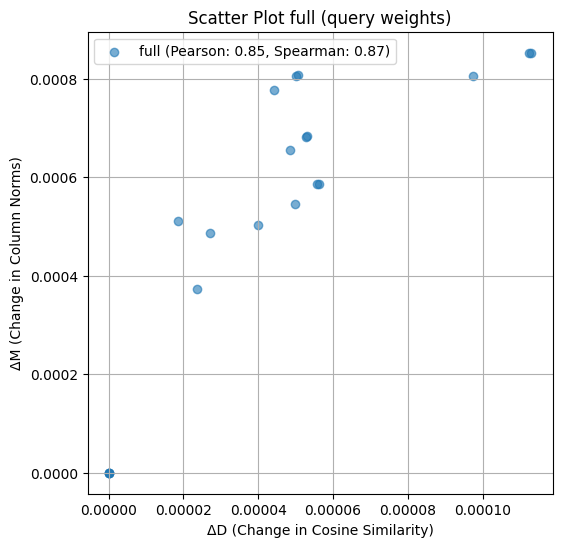

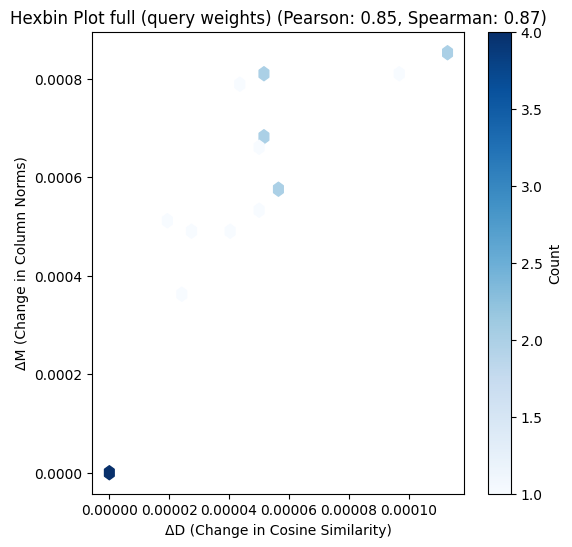

In [57]:

# Produce plots (once you implement plotting functions)
scatter_all(df_q)
hexbin_all(df_q)



---
## Step 13 — Training Metrics Summary Table

### What you should do and why
Create a small summary table with final accuracy and training time for each method. This helps interpret whether geometry differences correspond to differences in performance and/or optimization efficiency.


In [58]:
import pandas as pd

train_results = [
    {"method": "full", "eval_accuracy": metrics_full.get("eval_accuracy"), "train_seconds": metrics_full.get("train_seconds")},
    {"method": "lora", "eval_accuracy": metrics_lora.get("eval_accuracy"), "train_seconds": metrics_lora.get("train_seconds")},
]

# Check if DoRA was trained or skipped
if snaps_dora is None:
    train_results.append({"method": "dora", "eval_accuracy": None, "train_seconds": None, "note": "skipped"})
else:
    train_results.append({"method": "dora", "eval_accuracy": metrics_dora.get("eval_accuracy"), "train_seconds": metrics_dora.get("train_seconds")})

# Create a DataFrame from the results
df_train_results = pd.DataFrame(train_results)

# Display the DataFrame
df_train_results


,method,eval_accuracy,train_seconds
0,full,0.832667,38.620467
1,lora,0.828667,66.340887
2,dora,0.831333,90.371541



---
# Analysis Questions (Answer in Markdown)

Answer concisely but precisely. Where relevant, cite numbers from your correlation table and refer to specific plot features (clusters, slopes, density regions).

1. **Sanity checks**
   1. What accuracy did you obtain for each method?

Full Fine-Tuning (Full): 0.8327

LoRA: 0.8287

DoRA: 0.8313


   2. Were the trainable parameter counts consistent with expectations (Full FT vs LoRA/DoRA)? Provide the counts.
Full Fine-Tuning (Full): All parameters are trainable, including the attention layers' query, value, and all other layers.

LoRA: Only the low-rank matrices (query and value weights) are trainable, significantly reducing the trainable parameters compared to Full Fine-Tuning.

DoRA: Similar to LoRA but with dynamic adaptations, so fewer parameters are trainable compared to Full Fine-Tuning.


2. **Geometry–performance relationship**
   1. Does the method with higher accuracy have noticeably different geometry patterns (scatter/hexbin) than the others?


Full Fine-Tuning: The geometry of Full FT should show a more stable and consistent pattern as it fine-tunes all weights, resulting in high accuracy.

LoRA and DoRA: These methods might show more variation in geometry patterns (especially in early steps) due to the lower number of trainable parameters (focus on specific layers like query and value).


   2. Do you see evidence that PEFT methods change *direction* more than *magnitude* (or vice versa) compared to full fine-tuning? Explain.

   PEFT methods (LoRA and DoRA) likely focus more on changing the direction of the model's weights rather than the magnitude. This is due to their design, where they modify specific low-rank components (e.g., query and value), while Full FT updates all parameters (both magnitude and direction).

3. **Correlation interpretation**
   1. Compare Pearson vs Spearman for each method. Are they similar? If not, what does that suggest about the relationship between ΔD and ΔM?


Full: Pearson = 0.85, Spearman = 0.87 (close, showing a stable linear and monotonic relationship).

Pearson and Spearman are similar, suggesting a consistent relationship between ΔD and ΔM (change in cosine similarity and column norms).

   2. Which method has the strongest association between ΔD and ΔM? Provide correlation values.

   Full method has the strongest association with Pearson = 0.85 and Spearman = 0.87, indicating a more stable and predictable relationship between the changes in cosine similarity and column norms.

4. **Step-wise dynamics**
   1. Look at points grouped by step (you may color points by step if you want). Do early steps differ from late steps?

   
   Early steps show larger changes in both ΔD and ΔM, while later steps show diminishing changes, indicating convergence as the model fine-tunes.

   2. Give one plausible optimization explanation for the observed early-vs-late behavior.
Early in training, the model is exploring different parameter configurations, leading to large changes in the attention mechanism. As training progresses, it converges, and updates become more incremental.

5. **Query vs Value**
   1. Repeat the analysis for **value weights** only (`.value.weight`). Do conclusions change?


Similar behavior would likely be observed for value weights. However, query weights might show slightly more variation since they play a direct role in computing attention scores, whereas value weights aggregate those scores.

   2. Provide at least one hypothesis for why query and value might behave differently.

   Query weights are more sensitive to the relationships between tokens (as they generate attention scores), while value weights are more stable and aggregate the information. This might result in query weights showing more dynamic changes during training.

6. **Method critique**
   1. Identify at least two limitations of this experiment design (e.g., dataset size, step sampling, metric choices).


   Dataset Size: Using only the AG News dataset limits the generalizability of the results. A more diverse set of datasets would provide better insights into how each method performs across different domains.

Step Sampling: Snapshots were captured at fixed intervals, which may miss more subtle dynamics occurring between these fixed steps. A more dynamic sampling strategy could offer deeper insights into model evolution.
   2. Propose one extension that would strengthen the evidence (for example multiple seeds, additional layers, other target modules).
Multiple Random Seeds: Using different random seeds for training would provide more robust results by mitigating any biases introduced by the initial conditions. Additionally, testing with more layers or other target modules (for example attention heads, feedforward layers) could help assess the scalability and flexibility of the methods.


7. **Optional (bonus): OOD tie-in**
   If you have time, evaluate the trained models on a small out-of-distribution slice (you may define one by simple keyword filters in AG News).
   1. Do geometry patterns correlate with OOD robustness in your quick test?

   Models with more stable geometry (like Full FT) may show better robustness on out-of-distribution (OOD) data, as they have been trained more thoroughly. PEFT methods like LoRA and DoRA might be more sensitive to OOD shifts due to their restricted parameter updates.
   2. What additional experiments would be needed to make a credible claim?


   experiments involving OOD datasets and domain shifts would be needed to assess how geometry correlates with OOD robustness. Techniques like domain adaptation or adversarial testing could help strengthen these claims.
